In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [50]:
df = pd.read_csv("/content/drive/MyDrive/Python/synthetic_online_retail_data.csv")
print(df.head())

   customer_id  order_date  product_id  category_id       category_name  \
0        13542  2024-12-17         784           10         Electronics   
1        23188  2024-06-01         682           50   Sports & Outdoors   
2        55098  2025-02-04         684           50   Sports & Outdoors   
3        65208  2024-10-28         204           40  Books & Stationery   
4        63872  2024-05-10         202           20             Fashion   

  product_name  quantity   price payment_method            city  review_score  \
0   Smartphone         2  373.36    Credit Card  New Oliviaberg           1.0   
1  Soccer Ball         5  299.34    Credit Card    Port Matthew           NaN   
2         Tent         5   23.00    Credit Card      West Sarah           5.0   
3   Story Book         2  230.11  Bank Transfer  Hernandezburgh           5.0   
4        Skirt         4  176.72    Credit Card    Jenkinshaven           1.0   

  gender  age  
0      F   56  
1      M   59  
2      F   64 

In [51]:
print("Dataset Shape:", df.shape)
print(df.columns)
print(df.info())
print(df.describe())

Dataset Shape: (1000, 13)
Index(['customer_id', 'order_date', 'product_id', 'category_id',
       'category_name', 'product_name', 'quantity', 'price', 'payment_method',
       'city', 'review_score', 'gender', 'age'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     1000 non-null   int64  
 1   order_date      1000 non-null   object 
 2   product_id      1000 non-null   int64  
 3   category_id     1000 non-null   int64  
 4   category_name   1000 non-null   object 
 5   product_name    1000 non-null   object 
 6   quantity        1000 non-null   int64  
 7   price           1000 non-null   float64
 8   payment_method  1000 non-null   object 
 9   city            1000 non-null   object 
 10  review_score    799 non-null    float64
 11  gender          897 non-null    object 
 12  age             10

In [52]:
df.fillna(df.mean(numeric_only=True), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [53]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
print(df['order_date'].dtype)

datetime64[ns]


In [54]:
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("New Shape:", df.shape)


Duplicate Rows: 0
New Shape: (1000, 13)


In [55]:
df['Sales'] = df['quantity'] * df['price']
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 737326.8800000001


In [56]:
average_sales = df['Sales'].mean()
print("Average Sales:", average_sales)

Average Sales: 737.3268800000001


In [57]:
average_sales = df['Sales'].mean()

print("Average Sales:", average_sales)

Average Sales: 737.3268800000001


In [58]:
print("Maximum Sales:", df['Sales'].max())

print("Minimum Sales:", df['Sales'].min())

Maximum Sales: 2437.6499999999996
Minimum Sales: 20.84


Text(0, 0.5, 'Frequency')

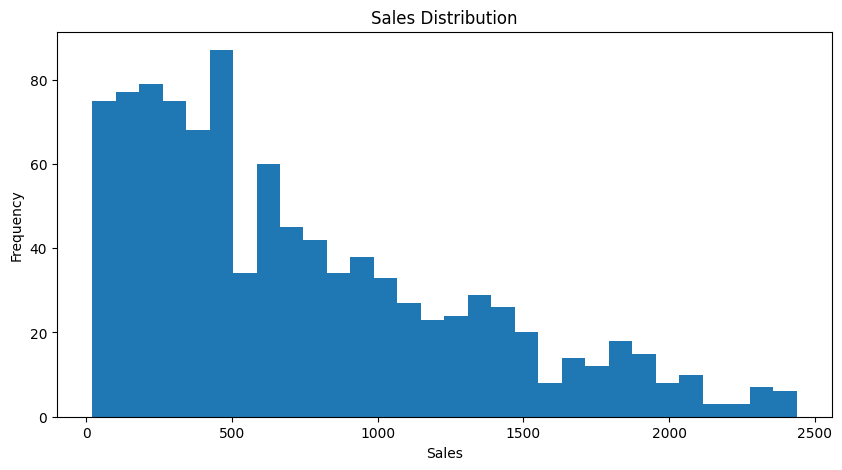

In [59]:
plt.figure(figsize=(10,5))

plt.hist(df['Sales'], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

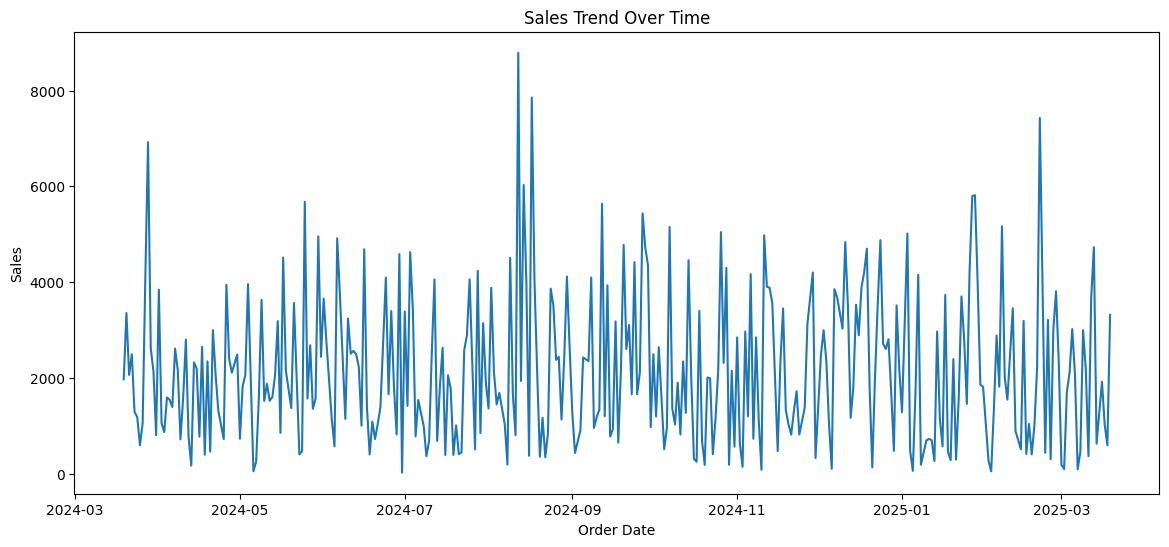

In [60]:
daily_sales = df.groupby('order_date')['Sales'].sum().reset_index()

plt.figure(figsize=(14,6))

plt.plot(daily_sales['order_date'], daily_sales['Sales'])

plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.show()

In [61]:
df['Month'] = df['order_date'].dt.month
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
1     60210.83
2     48826.04
3     61839.30
4     50375.40
5     61448.18
6     59127.40
7     57939.86
8     79070.12
9     69323.09
10    55328.98
11    55404.74
12    78432.94
Name: Sales, dtype: float64


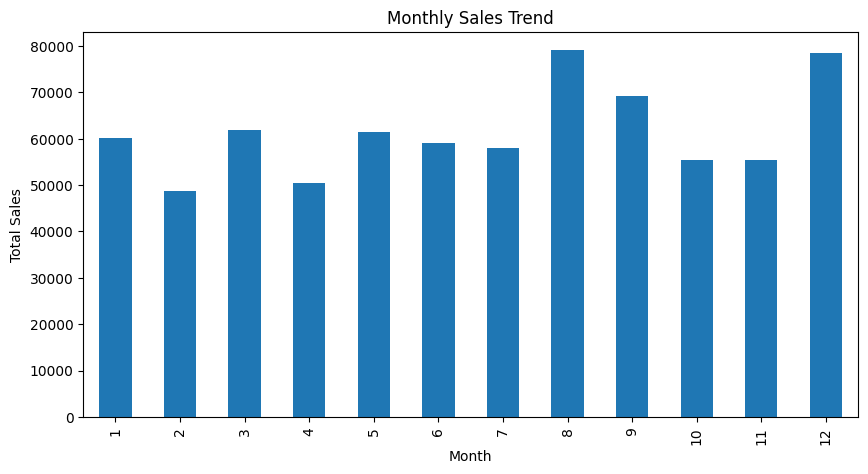

In [62]:
plt.figure(figsize=(10,5))

monthly_sales.plot(kind='bar')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

In [63]:
df['Year'] = df['order_date'].dt.year
yearly_sales = df.groupby('Year')['Sales'].sum()
print(yearly_sales)

Year
2024    597071.69
2025    140255.19
Name: Sales, dtype: float64


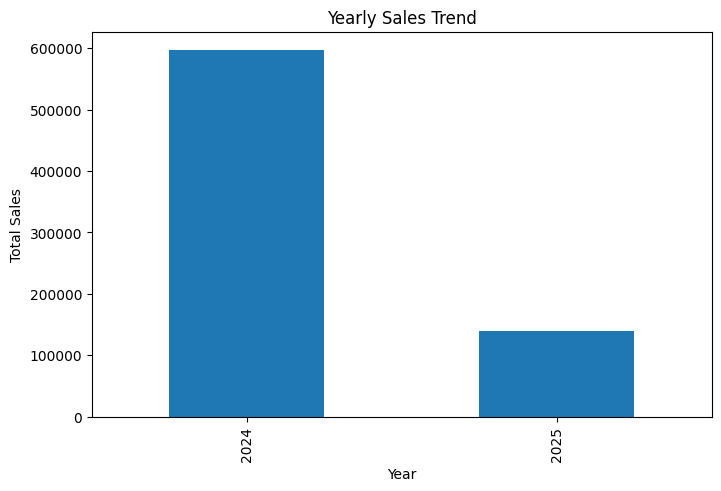

In [64]:
plt.figure(figsize=(8,5))

yearly_sales.plot(kind='bar')

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

In [65]:
category_sales = df.groupby('category_name')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

category_name
Electronics           166510.34
Sports & Outdoors     154346.26
Books & Stationery    143215.52
Home & Living         138540.15
Fashion               134714.61
Name: Sales, dtype: float64


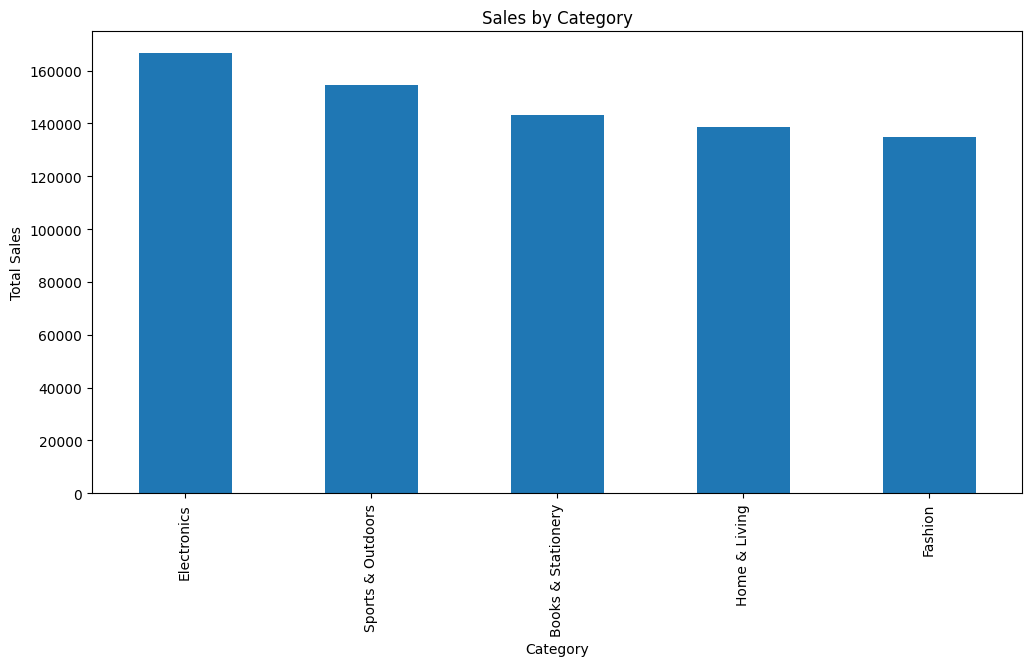

In [66]:
plt.figure(figsize=(12,6))

category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [67]:
product_sales = df.groupby('product_name')['Sales'].sum().sort_values(ascending=False)
print(product_sales.head(10))

product_name
Smartphone     38319.26
Notebook       38027.68
Yoga Mat       37752.08
Soccer Ball    37587.30
Tablet         33581.02
Vase           32191.58
Laptop         32000.38
Smartwatch     31820.10
Headphones     30789.58
T-shirt        30718.54
Name: Sales, dtype: float64


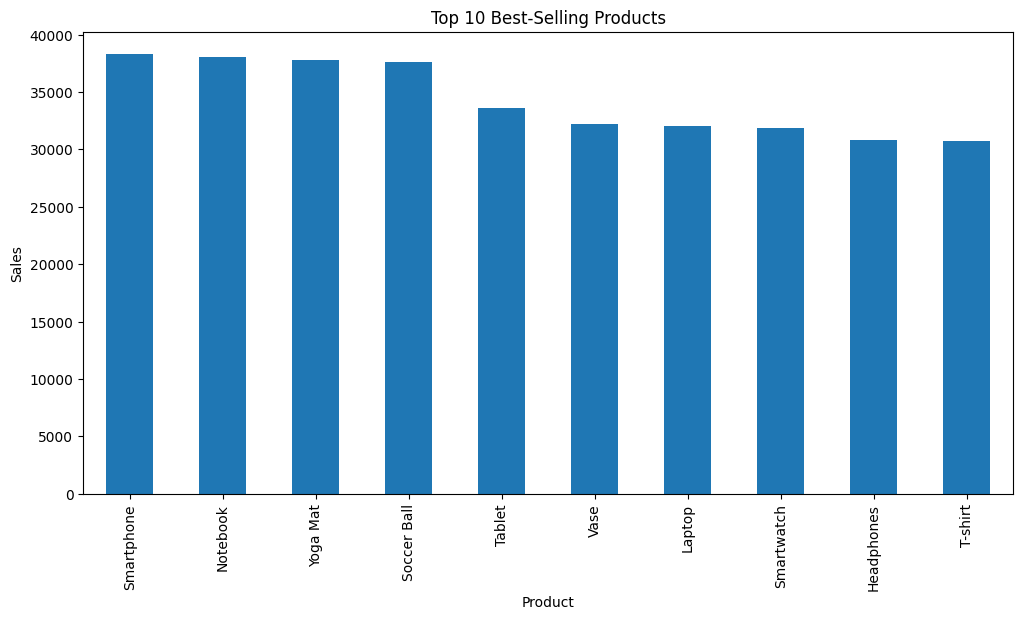

In [68]:
plt.figure(figsize=(12,6))

product_sales.head(10).plot(kind='bar')

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.show()

In [69]:
print(product_sales.tail(10))

product_name
Story Book    29062.57
Pillow        27095.93
Basketball    26282.05
Blanket       25867.20
Dress         25817.21
Carpet        24175.74
Tent          23449.52
Pen           23273.07
Novel         22750.81
Shirt         18230.94
Name: Sales, dtype: float64


In [70]:
daily_sales = df.groupby('order_date')['Sales'].sum()
print(daily_sales.head())

order_date
2024-03-19    1972.65
2024-03-20    3356.28
2024-03-21    2064.77
2024-03-22    2494.52
2024-03-23    1292.83
Name: Sales, dtype: float64


In [71]:
monthly_sales = df.groupby('Month')['Sales'].sum()

print(monthly_sales)

Month
1     60210.83
2     48826.04
3     61839.30
4     50375.40
5     61448.18
6     59127.40
7     57939.86
8     79070.12
9     69323.09
10    55328.98
11    55404.74
12    78432.94
Name: Sales, dtype: float64


In [72]:
yearly_growth = yearly_sales.pct_change() * 100
print(yearly_growth)

Year
2024          NaN
2025   -76.509489
Name: Sales, dtype: float64


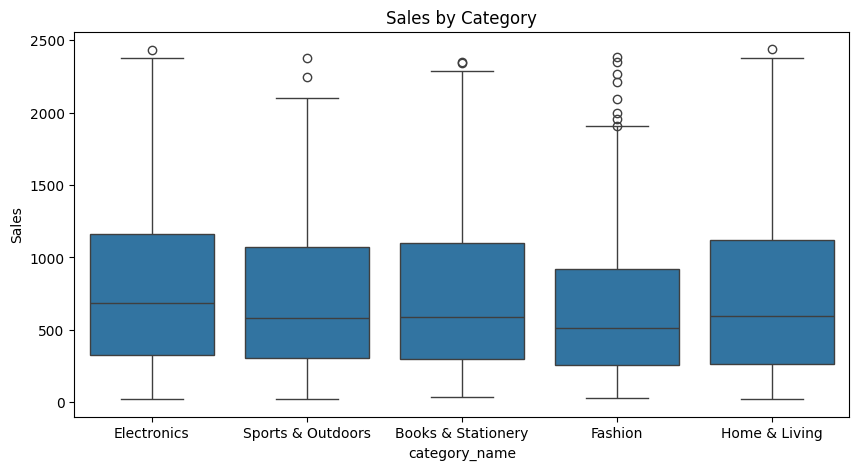

In [73]:
plt.figure(figsize=(10,5))

sns.boxplot(x='category_name', y='Sales', data=df)

plt.title("Sales by Category")

plt.show()

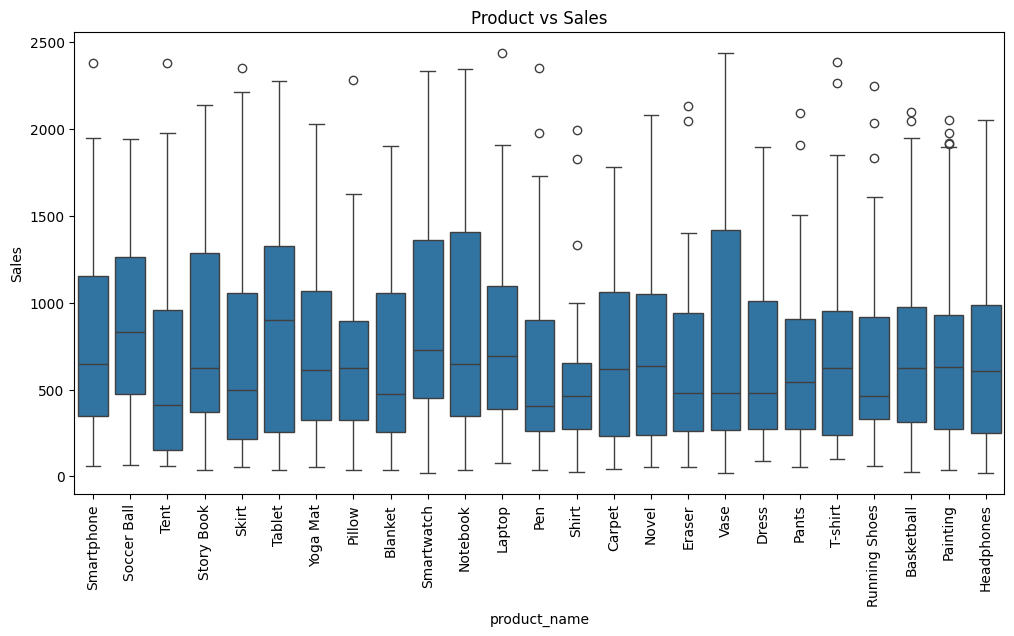

In [74]:
plt.figure(figsize=(12,6))

sns.boxplot(x='product_name', y='Sales', data=df)

plt.title("Product vs Sales")

plt.xticks(rotation=90)

plt.show()

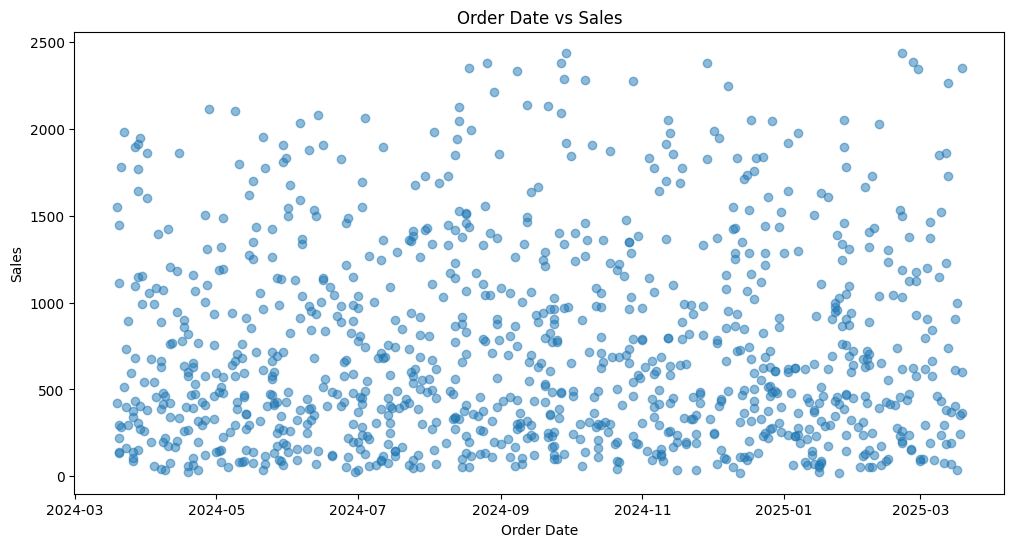

In [75]:
plt.figure(figsize=(12,6))

plt.scatter(df['order_date'], df['Sales'], alpha=0.5)

plt.title("Order Date vs Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.show()


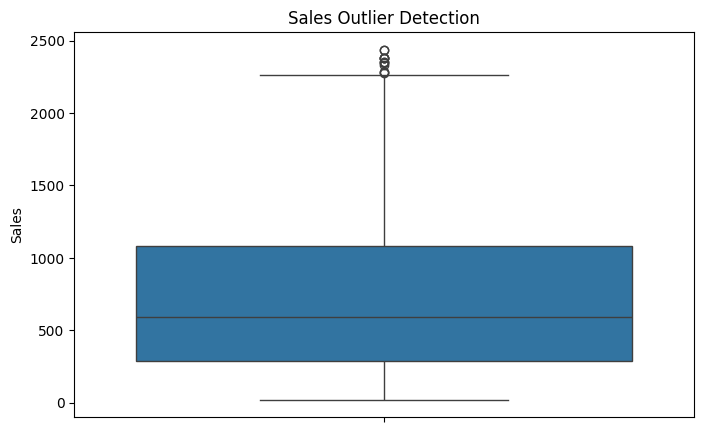

In [76]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Sales'])
plt.title("Sales Outlier Detection")
plt.show()

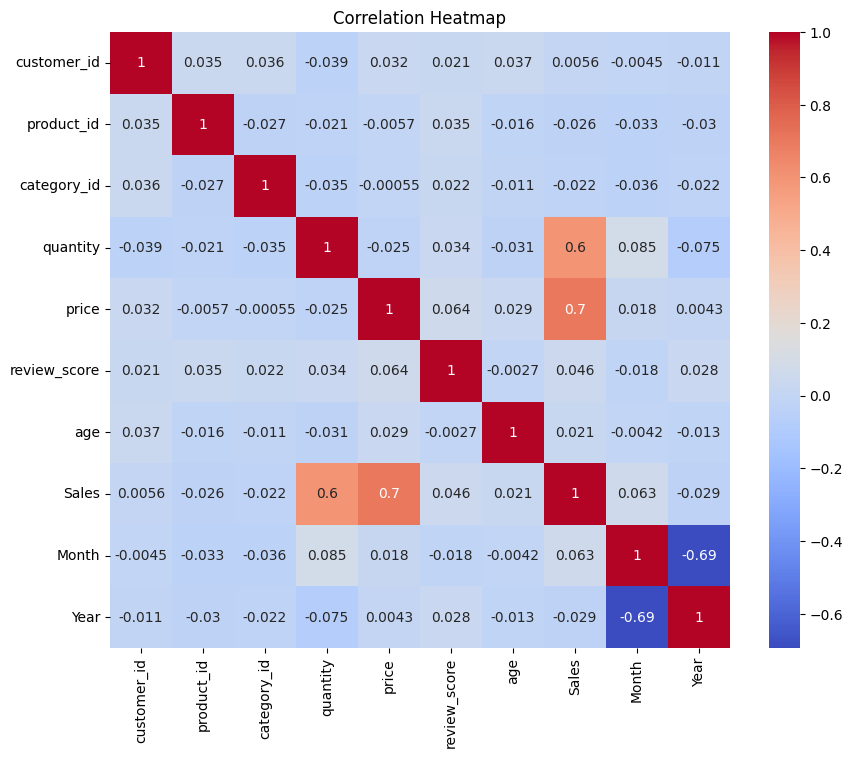

In [77]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()